# MR-NIRP NIR video and PulseOX visualization

Preview a short segment of NIR frames alongside the contact pulse oximeter (bpm) signal from the same clip.

**Prerequisite:** download at least one clip first:

```bash
uv sync --extra notebook
uv run python scripts/download.py --subjects 1 --scenes driving --motion-types still
```

In [51]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat
from scipy.signal import resample

from ir_stress.data.mr_nirp_driving import MRNIRPDrivingAdapter
from ir_stress.data.face_crop import read_pgm

PROJECT_ROOT = Path("..").resolve()
RAW_ROOT = PROJECT_ROOT / "data/raw/mr-nirp"
FPS = 30
Pulse_FPS = 60
START_FRAME = 300          # first frame to show
N_PREVIEW_FRAMES = 10       # frames shown in the montage
WINDOW_SEC = 100.0          # pulse ox window aligned to video segment

In [2]:
def load_pulseox(pulseox_path: Path) -> tuple[np.ndarray, np.ndarray]:
    """Load bpm waveform and relative time (seconds) from pulseOx.mat."""
    mat = loadmat(pulseox_path)
    if "pulseOxRecord" in mat:
        bpm = mat["pulseOxRecord"].squeeze().astype(np.float64)
        t = mat["pulseOxTime"].squeeze().astype(np.float64)
        t = t - t[0]
        return bpm, t
    if "data" in mat:
        bpm = mat["data"].squeeze().astype(np.float64)
        t = np.arange(len(bpm)) / float(mat.get("fs", [[400]])[0, 0])
        return bpm, t
    if "val" in mat:
        bpm = mat["val"].squeeze().astype(np.float64)
        t = np.arange(len(bpm))
        return bpm, t
    raise KeyError(f"Unknown pulseOx.mat layout: {list(mat.keys())}")


def list_pgm_frames(nir_dir: Path) -> list[Path]:
    return sorted(nir_dir.glob("Frame*.pgm"), key=lambda p: int(p.stem.replace("Frame", "")))

In [3]:
adapter = MRNIRPDrivingAdapter()
sessions = adapter.discover_sessions(RAW_ROOT, wavelengths=[940])
if not sessions:
    raise FileNotFoundError(
        f"No sessions under {RAW_ROOT}. Run scripts/download.py first."
    )

session = sessions[2]
frames = list_pgm_frames(session.nir_dir)
bpm, pulse_t = load_pulseox(session.pulseox_path)

print(f"Subject {session.subject_id} | {session.condition}")
print(f"NIR frames: {len(frames)} @ {FPS} fps ({len(frames) / FPS:.1f} s)")
print(f"PulseOX samples: {len(bpm)} ({pulse_t[-1]:.1f} s)")
print(f"Min value: {bpm.min()}, Max value: {bpm.max()}")

Subject 3 | subject3_driving_still_940
NIR frames: 12165 @ 30 fps (405.5 s)
PulseOX samples: 13046 (226.8 s)
Min value: 128.0, Max value: 226.0


In [5]:
from ir_stress.signals.baevsky import baevsky_stress_index

# Turn PulseOX into stress signal
# 1. Convert PulseOX to Stress Signal using Brevsky Stress Index

def convert_pulseox_to_stress_signal(pulseox: np.ndarray, window_t_sec: int = 10) -> np.ndarray:
    # Convert PulseOX to Stress Signal using Brevsky Stress Index
    # bsi_windowed = [baevsky_stress_index(pulseox[i*window_t:(i+1)*window_t])['baevsky_si'] for i in range(0, len(pulseox), window_t)]
    bsi_windowed = [baevsky_stress_index(pulseox[i:i+window_t_sec*Pulse_FPS])['baevsky_si'] for i in range(0, len(pulseox))]
    return bsi_windowed

In [6]:
end_frame = min(START_FRAME + int(WINDOW_SEC * FPS), len(frames))
preview_idx = np.linspace(
    START_FRAME,
    end_frame - 1,
    num=min(N_PREVIEW_FRAMES, end_frame - START_FRAME),
    dtype=int,
)

preview_images = [read_pgm(frames[i]) if i%2==0 else read_pgm(frames[i+1]) for i in preview_idx]
# preview_images = [(img-img.min()/img.max()-img.min()) for img in preview_images]
# preview_images = [cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX) for img in preview_images]
frame_times = preview_idx / FPS

t0 = START_FRAME / FPS
t1 = t0 + WINDOW_SEC
mask = (pulse_t >= t0) & (pulse_t <= t1)
window_bpm = bpm[mask]
window_t = pulse_t[mask]
window_stress = convert_pulseox_to_stress_signal(window_bpm)

# Mean NIR intensity trace (downsampled) for the same window
roi_frames = range(START_FRAME, end_frame)
mean_intensity = np.array(
    [read_pgm(frames[i]).mean() for i in roi_frames]
)
video_t = np.arange(len(mean_intensity)) / FPS + t0
bpm_at_video = resample(window_bpm, len(mean_intensity)) if len(window_bpm) > 1 else window_bpm

In [7]:
img = preview_images[1]
print(
        img.dtype,
        img.min(),
        img.max(),
        img.mean()
    )

float32 0.0039063096 0.9990387 0.30560338


/tmp/ipykernel_716011/3597486206.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


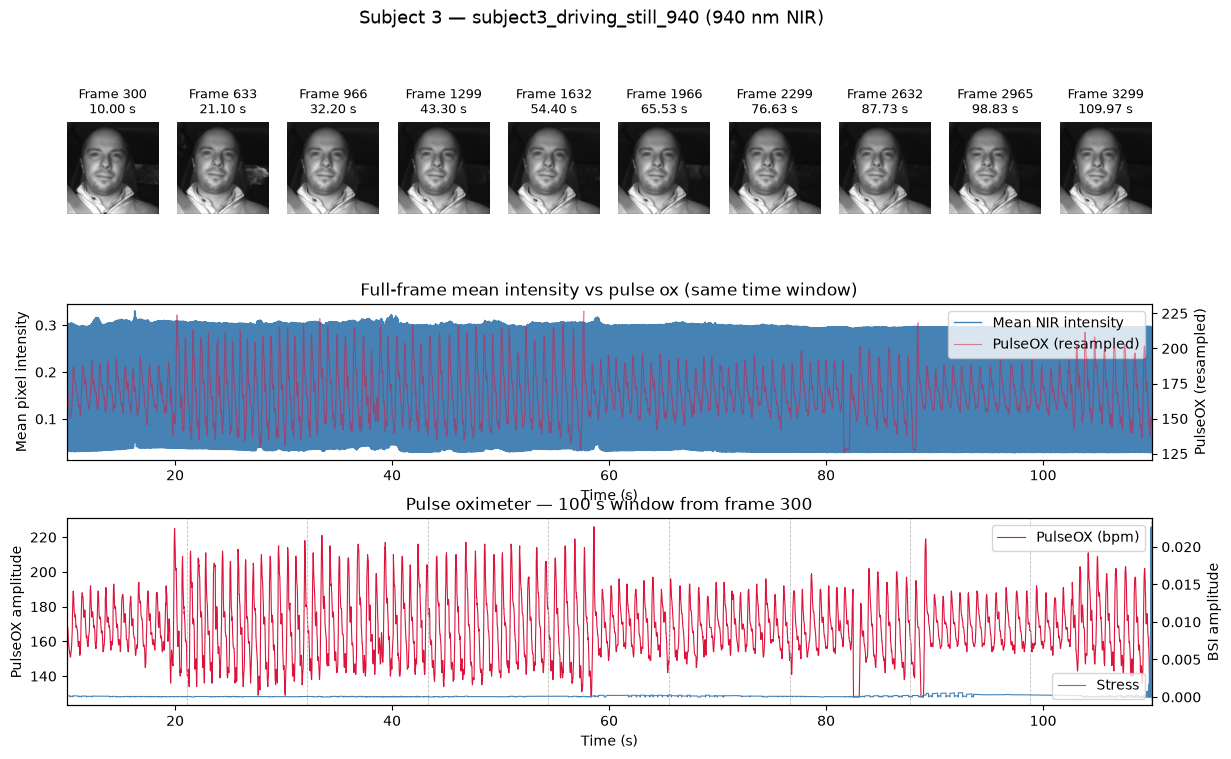

In [8]:
fig = plt.figure(figsize=(14, 8))
grid = fig.add_gridspec(3, len(preview_images), height_ratios=[1, 1, 1.2], hspace=0.35)

for col, (img, t, idx) in enumerate(zip(preview_images, frame_times, preview_idx)):
    ax = fig.add_subplot(grid[0, col])
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Frame {idx}\n{t:.2f} s", fontsize=9)
    ax.axis("off")

ax_pulse = fig.add_subplot(grid[2, :])
ax_pulse.plot(window_t, window_bpm, color="crimson", linewidth=0.8, label="PulseOX (bpm)")
for t in frame_times:
    ax_pulse.axvline(t, color="0.75", linewidth=0.6, linestyle="--")
ax_pulse.set_xlim(t0, t1)
ax_pulse.set_xlabel("Time (s)")
ax_pulse.set_ylabel("PulseOX amplitude")
ax_pulse.set_title(f"Pulse oximeter — {WINDOW_SEC:.0f} s window from frame {START_FRAME}")
ax_pulse.legend(loc="upper right")
ax_stress = ax_pulse.twinx()
ax_stress.plot(window_t, window_stress, color="steelblue", linewidth=0.8, label="Stress")
ax_stress.set_ylabel("BSI amplitude")
ax_stress.legend(loc="lower right")



ax_roi = fig.add_subplot(grid[1, :])
ax_roi.plot(video_t, mean_intensity, color="steelblue", linewidth=1.0, label="Mean NIR intensity")
ax_roi2 = ax_roi.twinx()
ax_roi2.plot(video_t, bpm_at_video, color="crimson", alpha=0.5, linewidth=0.8, label="PulseOX (resampled)")
ax_roi.set_xlim(t0, t1)
ax_roi.set_xlabel("Time (s)")
ax_roi.set_ylabel("Mean pixel intensity")
ax_roi2.set_ylabel("PulseOX (resampled)")
ax_roi.set_title("Full-frame mean intensity vs pulse ox (same time window)")
lines1, labels1 = ax_roi.get_legend_handles_labels()
lines2, labels2 = ax_roi2.get_legend_handles_labels()
ax_roi.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

fig.suptitle(
    f"Subject {session.subject_id} — {session.condition} ({session.wavelength} nm NIR)",
    fontsize=13,
    y=0.98,
)
fig.tight_layout()
plt.show()

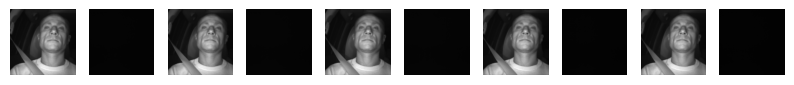

In [36]:
def get_frames_by_indices(start_index: int, end_index: int) -> list[np.ndarray]:
    frames = list_pgm_frames(session.nir_dir)
    return [read_pgm(frames[index]) for index in range(start_index, end_index)]
    
start_index = 390
end_index = 400
frames = get_frames_by_indices(start_index, end_index)
fig, ax = plt.subplots(1, len(frames), figsize=(10, 10))
for i, frame in enumerate(frames):
    ax[i].imshow(frame, cmap='gray')
    ax[i].axis('off')
plt.show()


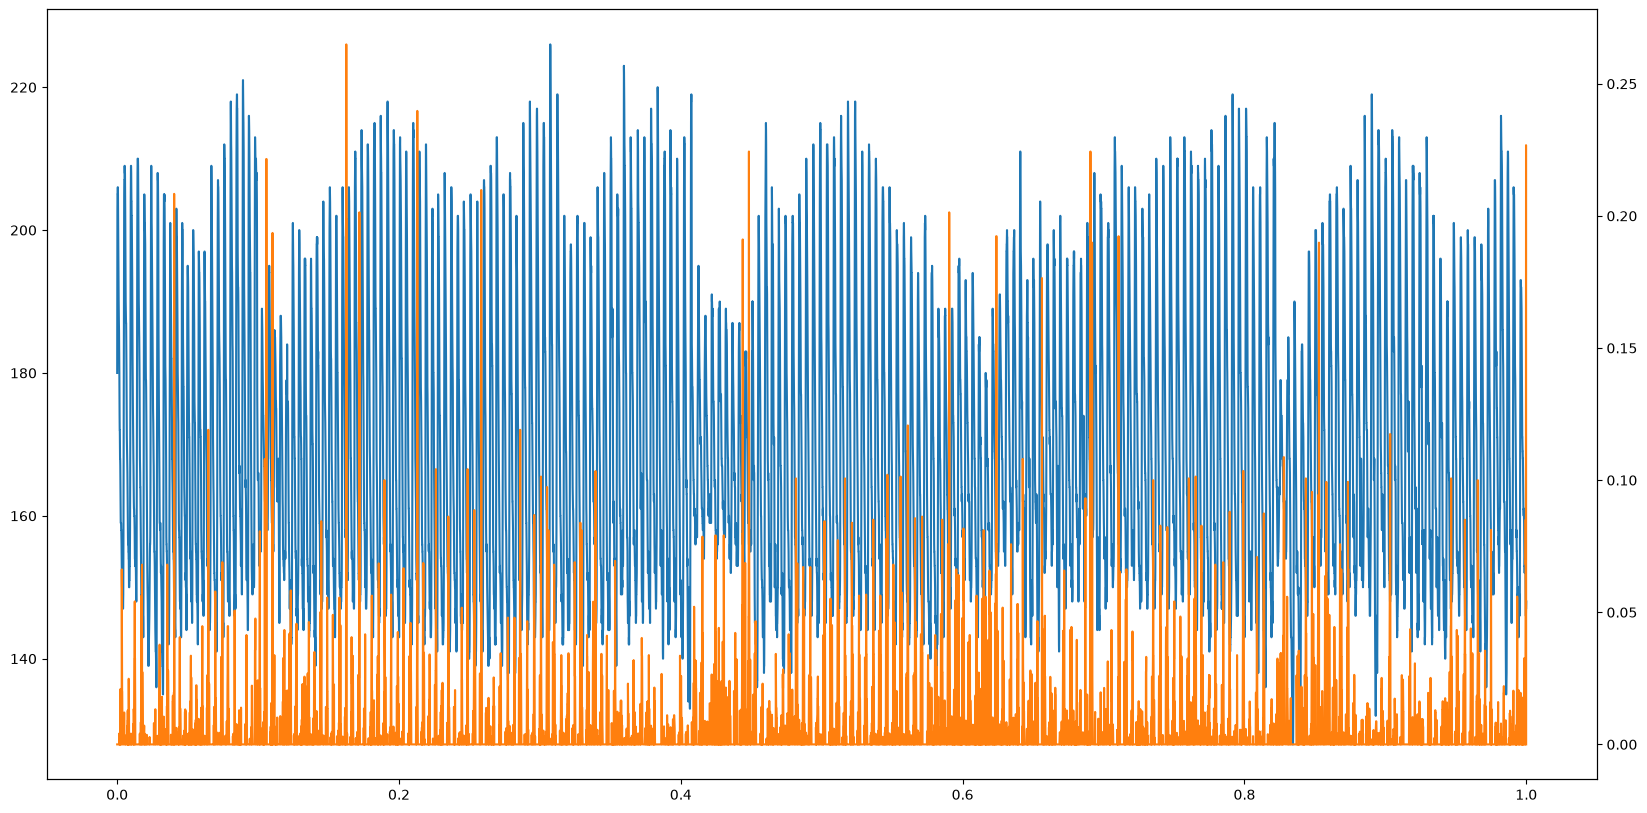

In [8]:
from ir_stress.signals.baevsky import baevsky_stress_index

# Turn PulseOX into stress signal
# 1. Convert PulseOX to Stress Signal using Brevsky Stress Index

def convert_pulseox_to_stress_signal(pulseox: np.ndarray, window_t: int = 10) -> np.ndarray:
    # Convert PulseOX to Stress Signal using Brevsky Stress Index
    # bsi_windowed = [baevsky_stress_index(pulseox[i*window_t:(i+1)*window_t])['baevsky_si'] for i in range(0, len(pulseox), window_t)]
    bsi_windowed = [baevsky_stress_index(pulseox[i:i+window_t])['baevsky_si'] for i in range(0, len(pulseox))]
    return bsi_windowed

# Plot the Stress Signal
pulseox = bpm
stress_signal = convert_pulseox_to_stress_signal(pulseox)
fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(np.linspace(0, 1, len(pulseox)), pulseox)
ax2 = ax.twinx()
ax2.plot(np.linspace(0, 1, len(stress_signal)), stress_signal, color='tab:orange')
plt.show()



In [ ]:
bpm.size, len(stress_signal)

(12264, 12264)

In [60]:
np.isnan(np.array(stress_signal)).sum()

np.int64(1)